#Project 2: Data Cleaning and Preparation


## 1. Import Libraries

I start by importing the libraries needed for data cleaning, transformation, visualization, and splitting the data.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

## 2. Load the Dataset

The data is loaded from the ZIP file used in Project 1. Since the stock price file is very large, I use a sample to make the notebook easier to run in Google Colab. To process the full dataset, remove the `nrows` option.

In [39]:
# Set the ZIP file path
zip_path = "Daily Historical Stock Prices (1970 - 2018).zip"

# Load the datasets
with zipfile.ZipFile(zip_path) as z:
    print("Files in ZIP:", z.namelist())

    stocks = pd.read_csv(z.open("historical_stocks.csv"))
    prices = pd.read_csv(
        z.open("historical_stock_prices.csv"),
        nrows=1500000
    )

# Check the size of each dataset
print("Prices shape:", prices.shape)
print("Stocks shape:", stocks.shape)

# Preview the first few rows
display(prices.head())
display(stocks.head())

Files in ZIP: ['historical_stock_prices.csv', 'historical_stocks.csv']
Prices shape: (1500000, 8)
Stocks shape: (6460, 5)


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


> **Observation:** The two datasets were loaded successfully. The stock price dataset contains daily price and volume information, while the stock dataset contains company information such as sector and industry.

## 3. Initial Data Inspection

I check the column names, data types, missing values, and duplicate records before making changes.

In [40]:
# Display column names and data types

print("Price columns:")
print(prices.columns)

print("\nPrice data types:")
print(prices.dtypes)

print("\nStock columns:")
print(stocks.columns)

print("\nStock data types:")
print(stocks.dtypes)

Price columns:
Index(['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date'], dtype='object')

Price data types:
ticker        object
open         float64
close        float64
adj_close    float64
low          float64
high         float64
volume         int64
date          object
dtype: object

Stock columns:
Index(['ticker', 'exchange', 'name', 'sector', 'industry'], dtype='object')

Stock data types:
ticker      object
exchange    object
name        object
sector      object
industry    object
dtype: object


> **Observation:** The datasets contain the expected columns. The date column is initially stored as an object, so it needs to be converted to datetime format before time-based analysis.

In [41]:
# Check for missing values

print("Missing values in prices:")
display(prices.isnull().sum())

print("\nMissing values in stocks:")
display(stocks.isnull().sum())

# Check for duplicate rows

print("\nDuplicate rows in prices:", prices.duplicated().sum())
print("Duplicate rows in stocks:", stocks.duplicated().sum())

Missing values in prices:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0



Missing values in stocks:


,0
ticker,0
exchange,0
name,0
sector,1440
industry,1440



Duplicate rows in prices: 0
Duplicate rows in stocks: 0


> **Observation:** This step checks whether there are missing values or duplicate rows. If missing values exist, they will be handled in the next section using appropriate methods.

## 4. Advanced Data Cleaning

This section handles missing values, duplicates, date formatting, and obvious data errors. For time-series stock data, forward filling and backward filling are useful because nearby values may provide a reasonable estimate.

In [42]:
# Make copies before cleaning so I can compare before and after
prices_before = prices.copy()
stocks_before = stocks.copy()

# Remove duplicate rows if any
prices = prices.drop_duplicates()
stocks = stocks.drop_duplicates()

# Convert date to datetime
prices['date'] = pd.to_datetime(prices['date'], errors='coerce')

# Sort by ticker and date so time-based filling and rolling calculations work correctly
prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)

# Handle missing numerical values using forward fill and backward fill within each ticker
price_numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']
prices[price_numeric_cols] = prices.groupby('ticker')[price_numeric_cols].ffill().bfill()

# Handle missing categorical values in stock information
stocks['sector'] = stocks['sector'].fillna('Unknown')
stocks['industry'] = stocks['industry'].fillna('Unknown')
stocks['exchange'] = stocks['exchange'].fillna('Unknown')

print('Missing values after cleaning prices:')
display(prices.isnull().sum())

print("\nMissing values after cleaning stocks:")
display(stocks.isnull().sum())

Missing values after cleaning prices:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0



Missing values after cleaning stocks:


,0
ticker,0
exchange,0
name,0
sector,0
industry,0


> **Observation:** Missing values were handled using forward and backward filling for stock prices and simple replacement for categorical company information. This keeps the dataset complete for future modeling.

### 4.1 Error Identification and Correction

Here I check for impossible or suspicious records, such as negative prices, negative volume, or cases where the high price is lower than the low price.

In [43]:
# Identify obvious data quality issues
invalid_price_rows = (prices[['open', 'high', 'low', 'close', 'adj_close']] < 0).any(axis=1)
invalid_volume_rows = prices['volume'] < 0
invalid_high_low_rows = prices['high'] < prices['low']
invalid_date_rows = prices['date'].isnull()

print('Negative price rows:', invalid_price_rows.sum())
print('Negative volume rows:', invalid_volume_rows.sum())
print('Rows where high < low:', invalid_high_low_rows.sum())
print('Invalid date rows:', invalid_date_rows.sum())

# Remove obvious invalid rows
prices = prices[~(invalid_price_rows | invalid_volume_rows | invalid_high_low_rows | invalid_date_rows)].copy()

print('Shape after removing invalid rows:', prices.shape)

Negative price rows: 0
Negative volume rows: 0
Rows where high < low: 0
Invalid date rows: 0
Shape after removing invalid rows: (1500000, 8)


> **Observation:** This step protects the integrity of the analysis by removing records that are clearly invalid or impossible for stock market data.

## 5. Outlier Detection and Treatment

Stock data often contains extreme values. Instead of deleting outliers, I use capping to reduce the effect of extreme values while keeping the records in the dataset.

In [44]:
def cap_outliers_iqr(df, column):
    # Cap outliers in a column using the IQR method
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    capped = df[column].clip(lower=lower, upper=upper)
    outliers = ((df[column] < lower) | (df[column] > upper)).sum()
    return capped, lower, upper, outliers

# Columns selected for outlier treatment
outlier_cols = ['close', 'volume']
outlier_summary = []

for col in outlier_cols:
    capped_values, lower, upper, count = cap_outliers_iqr(prices, col)
    prices[col + '_capped'] = capped_values
    outlier_summary.append({
        'column': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)

,column,lower_bound,upper_bound,outlier_count
0,close,-27.824134,6.404448e+01,132339
1,volume,-728300.000000,1.268500e+06,207978


> **Observation:** Outliers were detected using the IQR method. Capping was chosen instead of removal because extreme prices and volumes may represent real market events.

### 5.1 Before and After Outlier Treatment Visualization

/tmp/ipykernel_1552/3344213616.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([prices_before['close'].dropna(), prices['close_capped'].dropna()], labels=['Before', 'After Capping'])


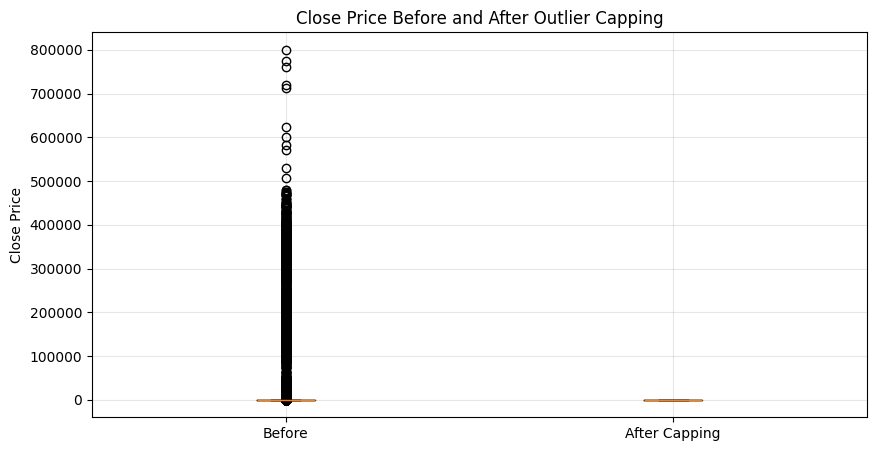

/tmp/ipykernel_1552/3344213616.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([np.log1p(prices_before['volume'].dropna()), np.log1p(prices['volume_capped'].dropna())], labels=['Before', 'After Capping'])


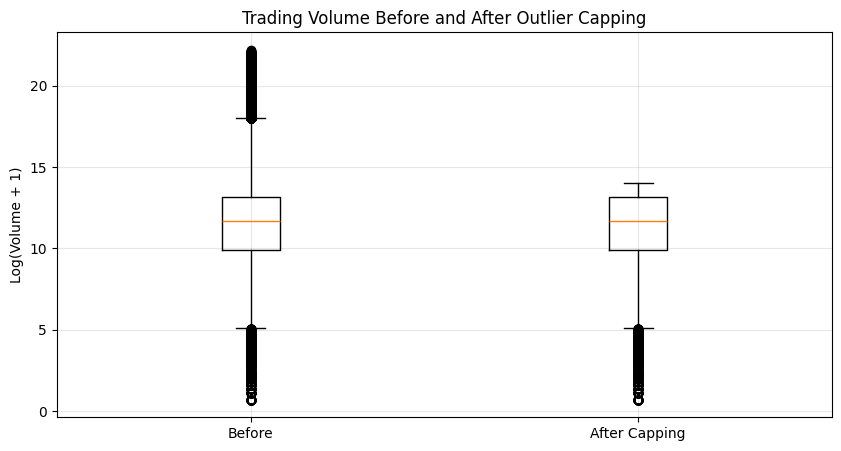

In [45]:
plt.figure(figsize=(10, 5))
plt.boxplot([prices_before['close'].dropna(), prices['close_capped'].dropna()], labels=['Before', 'After Capping'])
plt.title('Close Price Before and After Outlier Capping')
plt.ylabel('Close Price')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot([np.log1p(prices_before['volume'].dropna()), np.log1p(prices['volume_capped'].dropna())], labels=['Before', 'After Capping'])
plt.title('Trading Volume Before and After Outlier Capping')
plt.ylabel('Log(Volume + 1)')
plt.grid(True, alpha=0.3)
plt.show()

> **Observation:** The before-and-after plots show that capping reduces the influence of extreme values while preserving the overall structure of the dataset.

## 6. Data Transformation and Feature Engineering

New features are created to make the dataset more useful for future modeling. These features describe price movement, daily return, moving averages, and volatility.

In [46]:
# Create basic time features
prices['year'] = prices['date'].dt.year
prices['month'] = prices['date'].dt.month
prices['decade'] = (prices['year'] // 10) * 10

# Create price movement features
prices['price_range'] = prices['high'] - prices['low']
prices['daily_return'] = prices['close'] - prices['open']
prices['daily_return_pct'] = ((prices['close'] - prices['open']) / prices['open']).replace([np.inf, -np.inf], np.nan)

# Rolling features by ticker
prices['rolling_avg_7'] = prices.groupby('ticker')['close'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
prices['rolling_avg_30'] = prices.groupby('ticker')['close'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
prices['volatility_30'] = prices.groupby('ticker')['daily_return_pct'].transform(lambda x: x.rolling(window=30, min_periods=2).std())

# Fill remaining missing values created by percentage returns or rolling standard deviation
prices[['daily_return_pct', 'volatility_30']] = prices[['daily_return_pct', 'volatility_30']].fillna(0)

feature_cols = ['price_range', 'daily_return', 'daily_return_pct', 'rolling_avg_7', 'rolling_avg_30', 'volatility_30']
display(prices[['ticker', 'date', 'open', 'high', 'low', 'close'] + feature_cols].head(10))

,ticker,date,open,high,low,close,price_range,daily_return,daily_return_pct,rolling_avg_7,rolling_avg_30,volatility_30
0,AAPL,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.002232,0.000000,0.000000,0.513393,0.513393,0.000000
1,AAPL,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.002232,-0.002232,-0.004566,0.500000,0.500000,0.003229
2,AAPL,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.002232,-0.002232,-0.004926,0.483631,0.483631,0.002746
3,AAPL,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.002232,0.000000,0.000000,0.478237,0.478237,0.002744
4,AAPL,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.002232,0.000000,0.000000,0.477679,0.477679,0.002603
5,AAPL,1980-12-19,0.504464,0.506696,0.504464,0.504464,0.002232,0.000000,0.000000,0.482143,0.482143,0.002454
6,AAPL,1980-12-22,0.529018,0.531250,0.529018,0.529018,0.002232,0.000000,0.000000,0.488839,0.488839,0.002318
7,AAPL,1980-12-23,0.551339,0.553571,0.551339,0.551339,0.002232,0.000000,0.000000,0.494260,0.496652,0.002199
8,AAPL,1980-12-24,0.580357,0.582589,0.580357,0.580357,0.002232,0.000000,0.000000,0.507653,0.505952,0.002095
9,AAPL,1980-12-26,0.633929,0.636161,0.633929,0.633929,0.002232,0.000000,0.000000,0.533801,0.518750,0.002003


> **Observation:** New features were created to capture daily stock movement, short-term and longer-term trends, and volatility. These features can improve future machine learning models.

### 6.1 Rolling Average Visualization

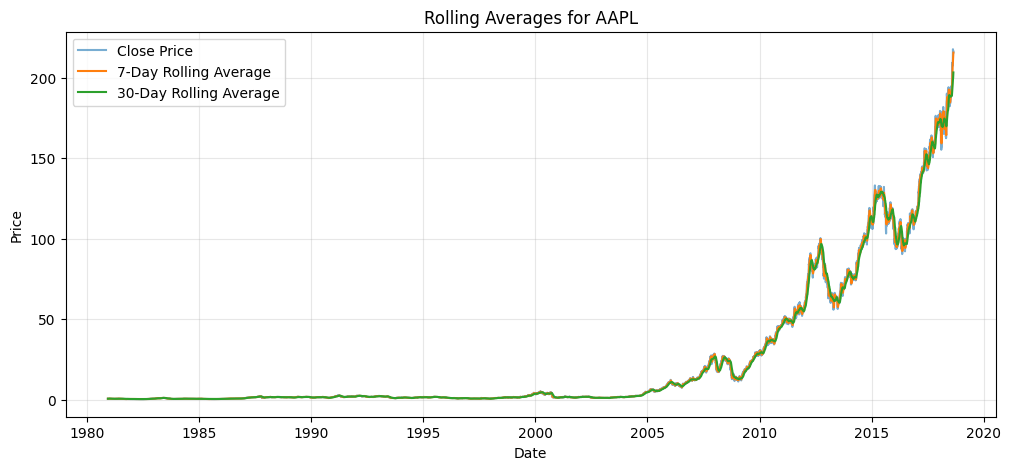

In [47]:
# Plot rolling averages for one sample ticker
sample_ticker = prices['ticker'].iloc[0]
sample_data = prices[prices['ticker'] == sample_ticker].copy()

plt.figure(figsize=(12, 5))
plt.plot(sample_data['date'], sample_data['close'], label='Close Price', alpha=0.6)
plt.plot(sample_data['date'], sample_data['rolling_avg_7'], label='7-Day Rolling Average')
plt.plot(sample_data['date'], sample_data['rolling_avg_30'], label='30-Day Rolling Average')
plt.title(f'Rolling Averages for {sample_ticker}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

> **Observation:** Rolling averages smooth daily price movements and make it easier to observe short-term and longer-term trends.

### 6.2 Volatility Visualization

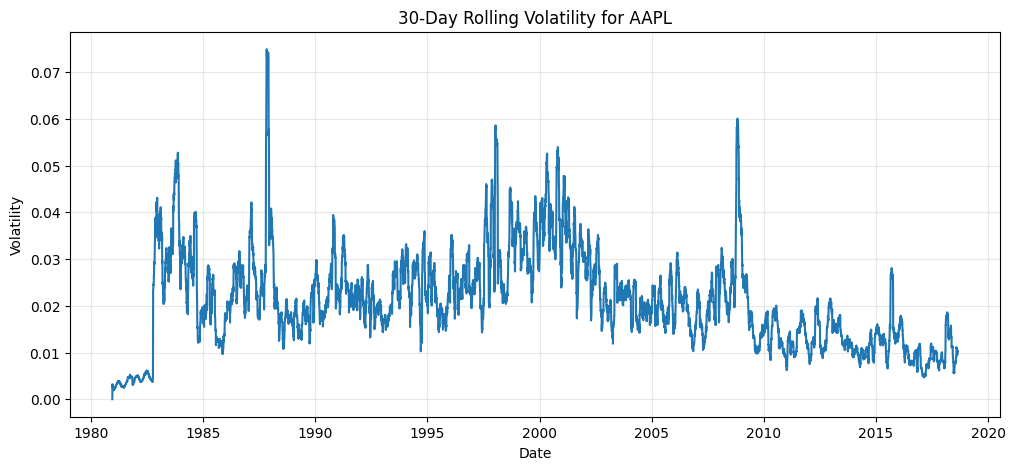

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(sample_data['date'], sample_data['volatility_30'])
plt.title(f'30-Day Rolling Volatility for {sample_ticker}')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True, alpha=0.3)
plt.show()

> **Observation:** Rolling volatility shows how much price movement changes over time. Higher volatility indicates greater uncertainty or stronger price fluctuations.

## 7. Merge Company Information

The stock price data is merged with company information so that sector and industry can be included in the final modeling dataset.

In [49]:
merged = prices.merge(stocks, on='ticker', how='left')

# Fill missing company information after merge
merged['sector'] = merged['sector'].fillna('Unknown')
merged['industry'] = merged['industry'].fillna('Unknown')
merged['exchange'] = merged['exchange'].fillna('Unknown')
merged['name'] = merged['name'].fillna('Unknown')

print('Merged dataset shape:', merged.shape)
display(merged.head())

Merged dataset shape: (1500000, 23)


,ticker,open,close,adj_close,low,high,volume,date,close_capped,volume_capped,year,month,decade,price_range,daily_return,daily_return_pct,rolling_avg_7,rolling_avg_30,volatility_30,exchange,name,sector,industry
0,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,1980-12-12,0.513393,1268500,1980,12,1980,0.002232,0.000000,0.000000,0.513393,0.513393,0.000000,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
1,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,1980-12-15,0.486607,1268500,1980,12,1980,0.002232,-0.002232,-0.004566,0.500000,0.500000,0.003229,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
2,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,1980-12-16,0.450893,1268500,1980,12,1980,0.002232,-0.002232,-0.004926,0.483631,0.483631,0.002746,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
3,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,1980-12-17,0.462054,1268500,1980,12,1980,0.002232,0.000000,0.000000,0.478237,0.478237,0.002744,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING
4,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,1980-12-18,0.475446,1268500,1980,12,1980,0.002232,0.000000,0.000000,0.477679,0.477679,0.002603,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING


> **Observation:** Merging the datasets created a richer dataset that includes both price information and company-level details such as sector and industry.

## 8. Normalization and Standardization

Scaling is useful for machine learning because it places numerical features on comparable scales. I use both Min-Max normalization and standardization.

In [50]:
# Select numerical columns for scaling
scale_cols = ['open', 'high', 'low', 'close', 'volume', 'price_range', 'daily_return', 'daily_return_pct', 'rolling_avg_7', 'rolling_avg_30', 'volatility_30']

# Create copies for scaling
model_data = merged.copy()

# Min-Max scaling
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(model_data[scale_cols])
minmax_cols = [col + '_minmax' for col in scale_cols]
model_data[minmax_cols] = minmax_scaled

# Standardization
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(model_data[scale_cols])
standard_cols = [col + '_standardized' for col in scale_cols]
model_data[standard_cols] = standard_scaled

display(model_data[minmax_cols + standard_cols].head())

,open_minmax,high_minmax,low_minmax,close_minmax,volume_minmax,price_range_minmax,daily_return_minmax,daily_return_pct_minmax,rolling_avg_7_minmax,rolling_avg_30_minmax,volatility_30_minmax,open_standardized,high_standardized,low_standardized,close_standardized,volume_standardized,price_range_standardized,daily_return_standardized,daily_return_pct_standardized,rolling_avg_7_standardized,rolling_avg_30_standardized,volatility_30_standardized
0,6.332160e-07,6.234738e-07,6.973839e-07,6.352926e-07,0.026153,1.340621e-08,0.305085,0.006388,7.096597e-07,1.051489e-06,0.000000,-0.032327,-0.032311,-0.032250,-0.032237,2.489767,-0.02402,-0.001138,-0.004490,-0.032352,-0.032808,-0.106394
1,6.026339e-07,5.907684e-07,6.606408e-07,6.018209e-07,0.009807,1.340639e-08,0.305085,0.006359,6.908909e-07,1.023680e-06,0.000051,-0.032330,-0.032315,-0.032254,-0.032241,0.889415,-0.02402,-0.001145,-0.024780,-0.032354,-0.032809,-0.093289
2,5.581508e-07,5.471612e-07,6.116500e-07,5.571920e-07,0.005895,1.340621e-08,0.305085,0.006357,6.679513e-07,9.896904e-07,0.000043,-0.032334,-0.032319,-0.032258,-0.032245,0.506416,-0.02402,-0.001145,-0.026379,-0.032356,-0.032811,-0.095248
3,5.692716e-07,5.607884e-07,6.269596e-07,5.711385e-07,0.004820,1.340621e-08,0.305085,0.006388,6.603916e-07,9.784895e-07,0.000043,-0.032333,-0.032318,-0.032257,-0.032244,0.401128,-0.02402,-0.001138,-0.004490,-0.032356,-0.032812,-0.095256
4,5.859527e-07,5.771411e-07,6.453312e-07,5.878743e-07,0.004096,1.340621e-08,0.305085,0.006388,6.596096e-07,9.773307e-07,0.000041,-0.032331,-0.032316,-0.032255,-0.032242,0.330203,-0.02402,-0.001138,-0.004490,-0.032356,-0.032812,-0.095830


> **Observation:** Normalization and standardization transformed the numerical variables so they can be used more effectively in future machine learning models.

### 8.1 Scaling Comparison Visualization

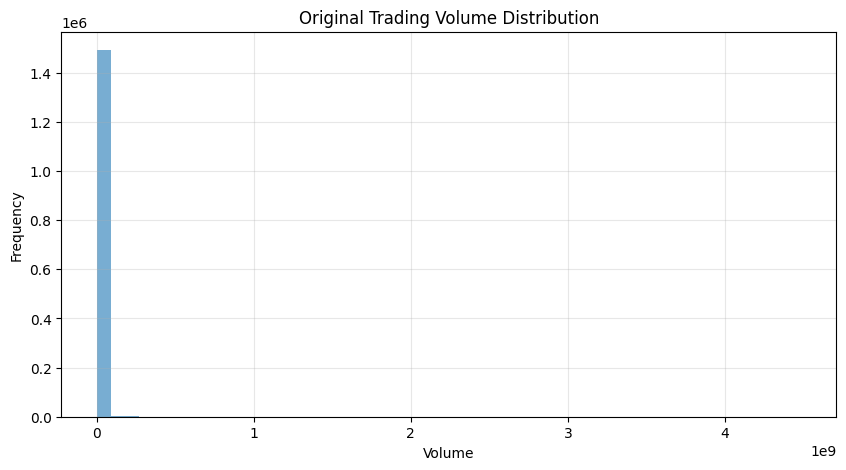

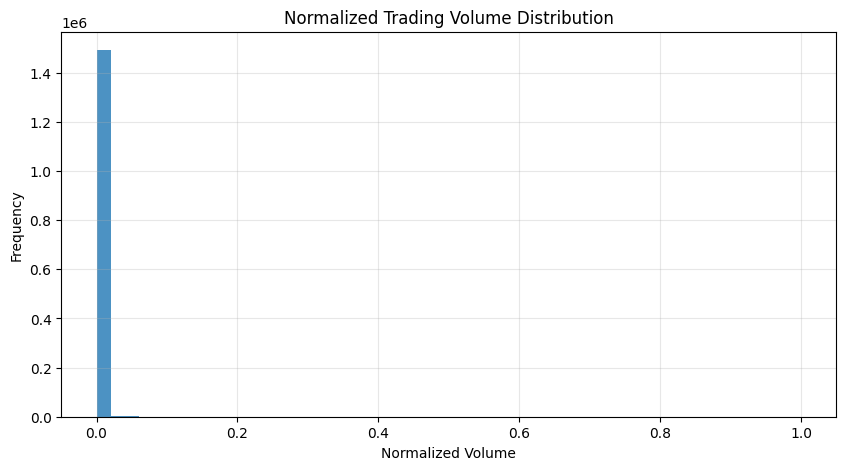

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(model_data['volume'].dropna(), bins=50, alpha=0.6, label='Original Volume')
plt.title('Original Trading Volume Distribution')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(model_data['volume_minmax'].dropna(), bins=50, alpha=0.8)
plt.title('Normalized Trading Volume Distribution')
plt.xlabel('Normalized Volume')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

> **Observation:** Scaling changes the range of the data while keeping the overall distribution pattern. This prepares numerical variables for modeling algorithms that are sensitive to scale.

## 9. Encode Categorical Variables

Machine learning models require numerical inputs, so categorical variables such as sector and exchange are encoded using one-hot encoding.

In [52]:
# One-hot encode selected categorical columns
encoded_data = pd.get_dummies(model_data, columns=['sector', 'exchange'], drop_first=True)

print('Shape before encoding:', model_data.shape)
print('Shape after encoding:', encoded_data.shape)

display(encoded_data.head())

Shape before encoding: (1500000, 45)
Shape after encoding: (1500000, 56)


,ticker,open,close,adj_close,low,high,volume,date,close_capped,volume_capped,year,month,decade,price_range,daily_return,daily_return_pct,rolling_avg_7,rolling_avg_30,volatility_30,name,industry,open_minmax,high_minmax,low_minmax,close_minmax,...,volatility_30_minmax,open_standardized,high_standardized,low_standardized,close_standardized,volume_standardized,price_range_standardized,daily_return_standardized,daily_return_pct_standardized,rolling_avg_7_standardized,rolling_avg_30_standardized,volatility_30_standardized,sector_CAPITAL GOODS,sector_CONSUMER DURABLES,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_TRANSPORTATION,sector_Unknown,exchange_NYSE
0,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,1980-12-12,0.513393,1268500,1980,12,1980,0.002232,0.000000,0.000000,0.513393,0.513393,0.000000,APPLE INC.,COMPUTER MANUFACTURING,6.332160e-07,6.234738e-07,6.973839e-07,6.352926e-07,...,0.000000,-0.032327,-0.032311,-0.032250,-0.032237,2.489767,-0.02402,-0.001138,-0.004490,-0.032352,-0.032808,-0.106394,False,False,False,False,False,False,False,False,False,True,False,False,False
1,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,1980-12-15,0.486607,1268500,1980,12,1980,0.002232,-0.002232,-0.004566,0.500000,0.500000,0.003229,APPLE INC.,COMPUTER MANUFACTURING,6.026339e-07,5.907684e-07,6.606408e-07,6.018209e-07,...,0.000051,-0.032330,-0.032315,-0.032254,-0.032241,0.889415,-0.02402,-0.001145,-0.024780,-0.032354,-0.032809,-0.093289,False,False,False,False,False,False,False,False,False,True,False,False,False
2,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,1980-12-16,0.450893,1268500,1980,12,1980,0.002232,-0.002232,-0.004926,0.483631,0.483631,0.002746,APPLE INC.,COMPUTER MANUFACTURING,5.581508e-07,5.471612e-07,6.116500e-07,5.571920e-07,...,0.000043,-0.032334,-0.032319,-0.032258,-0.032245,0.506416,-0.02402,-0.001145,-0.026379,-0.032356,-0.032811,-0.095248,False,False,False,False,False,False,False,False,False,True,False,False,False
3,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,1980-12-17,0.462054,1268500,1980,12,1980,0.002232,0.000000,0.000000,0.478237,0.478237,0.002744,APPLE INC.,COMPUTER MANUFACTURING,5.692716e-07,5.607884e-07,6.269596e-07,5.711385e-07,...,0.000043,-0.032333,-0.032318,-0.032257,-0.032244,0.401128,-0.02402,-0.001138,-0.004490,-0.032356,-0.032812,-0.095256,False,False,False,False,False,False,False,False,False,True,False,False,False
4,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,1980-12-18,0.475446,1268500,1980,12,1980,0.002232,0.000000,0.000000,0.477679,0.477679,0.002603,APPLE INC.,COMPUTER MANUFACTURING,5.859527e-07,5.771411e-07,6.453312e-07,5.878743e-07,...,0.000041,-0.032331,-0.032316,-0.032255,-0.032242,0.330203,-0.02402,-0.001138,-0.004490,-0.032356,-0.032812,-0.095830,False,False,False,False,False,False,False,False,False,True,False,False,False


> **Observation:** One-hot encoding converted categorical variables into numerical columns, making the dataset suitable for machine learning models.

## 10. Prepare Modeling Dataset

The final dataset is cleaned, transformed, encoded, and ready for modeling. I select useful features and split the dataset into training, validation, and test sets.

In [53]:
# Define a practical modeling dataset
# The target variable here is close price, which could be used in a future prediction model.
target = 'close'

# Remove columns that are identifiers or not directly suitable as model inputs
columns_to_drop = ['date', 'name', 'industry', target]
available_drop_cols = [col for col in columns_to_drop if col in encoded_data.columns]

X = encoded_data.drop(columns=available_drop_cols)
y = encoded_data[target]

# Keep only numeric features
X = X.select_dtypes(include=[np.number, 'bool']).copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print('Training set:', X_train.shape, y_train.shape)
print('Validation set:', X_val.shape, y_val.shape)
print('Test set:', X_test.shape, y_test.shape)

Training set: (1050000, 51) (1050000,)
Validation set: (225000, 51) (225000,)
Test set: (225000, 51) (225000,)


> **Observation:** The dataset was split into training, validation, and test sets. This prepares the data for future model training, tuning, and final evaluation.

## 11. Save Cleaned Data and Splits

The cleaned dataset and modeling splits are saved as CSV files for future use.

In [54]:
# Create output folder
output_folder = 'project2_outputs'
os.makedirs(output_folder, exist_ok=True)

# Combine X and y for saving splits
train_data = X_train.copy()
train_data[target] = y_train.values

validation_data = X_val.copy()
validation_data[target] = y_val.values

test_data = X_test.copy()
test_data[target] = y_test.values

# Save outputs
model_data.to_csv(os.path.join(output_folder, 'cleaned_stock_data.csv'), index=False)
train_data.to_csv(os.path.join(output_folder, 'train_data.csv'), index=False)
validation_data.to_csv(os.path.join(output_folder, 'validation_data.csv'), index=False)
test_data.to_csv(os.path.join(output_folder, 'test_data.csv'), index=False)

print('Files saved successfully in:', output_folder)
print(os.listdir(output_folder))

Files saved successfully in: project2_outputs
['validation_data.csv', 'train_data.csv', 'test_data.csv', 'cleaned_stock_data.csv']


> **Observation:** The cleaned dataset and the train, validation, and test splits were saved successfully. These files can be used in future modeling tasks without repeating all cleaning and transformation steps.

## 12. Final Summary

In this project, I prepared the historical stock price data for future machine learning analysis. The process included advanced cleaning, outlier detection and capping, feature engineering, scaling, one-hot encoding, and data splitting.

The final dataset is cleaner, better structured, and more suitable for predictive modeling than the original raw dataset.